In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.preprocessing import StandardScaler

**IMPLEMENTASI FUNGSI**

In [ ]:
def softmax(z):
    # Rumus: exp(wc @ x + bc) / sum(exp(wk @ x + bk)) [cite: 228, 235]
    # Stabilkan untuk mencegah overflow (angka terlalu besar)
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [ ]:
def cross_entropy_loss(y_pred, y_true):
    # Rumus: L = -1/n * sum(log f_yi(xi)) [cite: 152, 158, 284]
    n = y_pred.shape[0]
    log_p = -np.log(y_pred[range(n), y_true] + 1e-15)
    return np.mean(log_p)

**DATA PREPROCESSING**

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# Membaca data dari Colab
df = pd.read_csv('/content/gdrive/My Drive/Tugas AI Ketiga/train.csv')

In [ ]:
# Fitur: ram dan battery_power
X = df[['ram', 'battery_power']].values
y = df['price_range'].values # Target: 0, 1, 2, 3

In [ ]:
# Normalisasi Fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Bagi data menjadi Training dan Testing (80:20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


**PELATIHAN MODEL (STOCHASTIC GRADIENT DESCENT)**

In [ ]:
# Inisialisasi Parameter: V(D + 1) = 4(2 + 1) = 12 parameters [cite: 24, 25]
input_dim = 2
num_classes = 4
W = np.random.randn(input_dim, num_classes) * 0.01
b = np.zeros(num_classes)

lr = 0.1 # Learning rate (eta) [cite: 96, 273]
epochs = 300
loss_history = []

for i in range(epochs):
    # Forward Pass: f(x) = softmax(W @ x + b) [cite: 21, 232]
    scores = np.dot(X_train, W) + b
    probs = softmax(scores)

    # Hitung Error (epsilon): f_c(x) - 1 (jika benar) atau f_c(x) (jika salah) [cite: 269, 275, 286]
    error = probs.copy()
    error[range(len(y_train)), y_train] -= 1

    # Update Parameter (SGD): w_c = w_c - eta * epsilon * x [cite: 273, 288]
    dW = np.dot(X_train.T, error) / len(y_train)
    db = np.mean(error, axis=0)

    W -= lr * dW
    b -= lr * db

    if i % 30 == 0:
        loss = cross_entropy_loss(probs, y_train)
        loss_history.append(loss)
        print(f"Epoch {i}, Loss: {loss:.4f}")

Epoch 0, Loss: 1.3823
Epoch 30, Loss: 1.0334
Epoch 60, Loss: 0.9103
Epoch 90, Loss: 0.8414
Epoch 120, Loss: 0.7939
Epoch 150, Loss: 0.7579
Epoch 180, Loss: 0.7291
Epoch 210, Loss: 0.7053
Epoch 240, Loss: 0.6851
Epoch 270, Loss: 0.6676


**VISUALISASI HASIL (VORONOI REGIONS)**

In [ ]:
plt.figure(figsize=(10, 6))

# Membuat grid untuk background warna (Wilayah Klasifikasi)
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

<Figure size 1000x600 with 0 Axes>

In [ ]:
# Prediksi seluruh grid untuk melihat batas wilayah
Z = np.dot(np.c_[xx.ravel(), yy.ravel()], W) + b
Z = np.argmax(Z, axis=1).reshape(xx.shape)

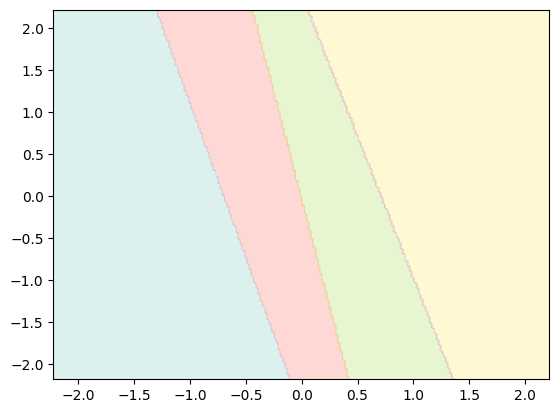

In [ ]:
# Plot wilayah (Voronoi Regions)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set3')

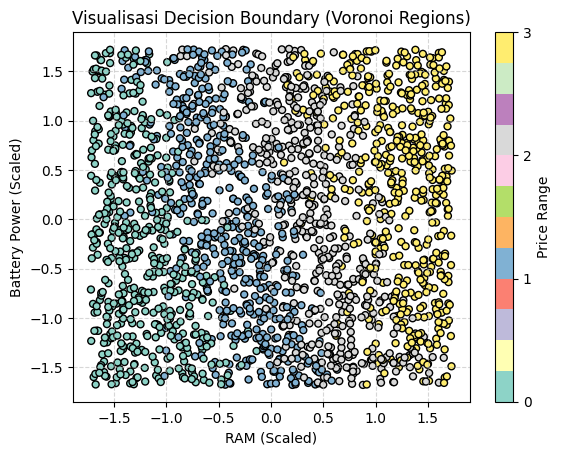

In [ ]:
# Plot titik data asli
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='k', s=25, cmap='Set3')
plt.colorbar(scatter, ticks=[0, 1, 2, 3], label='Price Range')
plt.title("Visualisasi Decision Boundary (Voronoi Regions)")
plt.xlabel("RAM (Scaled)")
plt.ylabel("Battery Power (Scaled)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()